# Loading your BWK sample points.
## Loading packages
Let's start with installing the required packages.

In [21]:
%pip install "geotessera==0.8.0"

In [22]:
try:
    import ee, geemap
except ImportError:
    !pip -q install earthengine-api geemap

import ee, geemap, datetime # ee: Google Earth Engine (GEE) API, geemap: mapping GEE products
import pandas as pd
import matplotlib.pyplot as plt # for figure plotting
import geopandas as gpd # for geospatial dataframes
import os

In [23]:
%pip install "leafmap[maplibre]" # For interactive visualization of maps.
from maplibre.plugins import MapboxDrawControls, MapboxDrawOptions # To select ROI's on your maps.

Connect to your Google Drive to load your dataset within your drive.

In [24]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


Load your geospatial dataset.

In [25]:
grasslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/Grassland_classified_final_classes_2023.gpkg")
nograsslands = gpd.read_file("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/BWK - graslandfases/selecties/NoGrassland_classified_final_classes_2023.gpkg")

Create a random subset of nograsslands of +/- 30% of the grasslands dataset.

In [26]:
samplesize = round(len(grasslands) * 30  / 100)
samplesize

54

In [27]:
nograsslands_samp = nograsslands.sample(n=samplesize, random_state=42)
len(nograsslands_samp)

54

Combine the datasets

In [28]:
list(grasslands)

['lg_2022',
 'lg_2016',
 'lg_2017',
 'lg_2018',
 'lg_2019',
 'lg_2020',
 'lg_2021',
 'l_7_BWK',
 'lg_2023',
 'Tl_2023',
 'l_8_BWK',
 'FID_BWK',
 'OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABE',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHA',
 'HABLEGE',
 'LENGTE',
 'OPPERVL',
 'FID_L20',
 'ORIG_FI',
 'Shp_Lng',
 'Shap_Ar',
 'combi',
 'Level1',
 'Level2',
 'Level3',
 'Level4',
 'Level5',
 'Level4_int_class',
 'geometry']

In [29]:
list(nograsslands_samp)

['OIDN',
 'UIDN',
 'TAG',
 'EVAL',
 'EENH1',
 'EENH2',
 'EENH3',
 'EENH4',
 'EENH5',
 'EENH6',
 'EENH7',
 'EENH8',
 'V1',
 'V2',
 'V3',
 'HERK',
 'INFO',
 'BWKLABEL',
 'HAB1',
 'PHAB1',
 'HAB2',
 'PHAB2',
 'HAB3',
 'PHAB3',
 'HAB4',
 'PHAB4',
 'HAB5',
 'PHAB5',
 'HERKHAB',
 'HERKPHAB',
 'HABLEGENDE',
 'LENGTE',
 'OPPERVL',
 'geometry']

In [30]:
nograsslands_samp = nograsslands_samp.assign(Level4='nograss')

Combine the 2 datasets

In [31]:
nograsslands_samp = nograsslands_samp.to_crs(grasslands.crs)

datagrassbwk2023 = pd.concat([grasslands, nograsslands_samp])
datagrassbwk2023

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((210639.5 176026.668, 210670.31...",NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((149853.269 223793.793, 149868....",NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((149718.149 224040.117, 149718....",NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((149689.553 224014.322, 149718....",NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,"MULTIPOLYGON (((157080.781 233460.18, 156758.2...",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((200132.032 162108.059, 200113....",bl,a,gh
5259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((50815.371 196977.204, 50761.33...",qs° + kbf + pins,2310,hab
16985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((97137.412 217338.297, 97076.95...",bl + bu,a,gh
23636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,"MULTIPOLYGON (((231730.75 211937.313, 231733.1...",kbac,235,gh


Convert multipolygon to points.

In [32]:
datagrassbwk2023["geometry"] = datagrassbwk2023.geometry.centroid
datagrassbwk2023

,lg_2022,lg_2016,lg_2017,lg_2018,lg_2019,lg_2020,lg_2021,l_7_BWK,lg_2023,Tl_2023,...,Level1,Level2,Level3,Level4,Level5,Level4_int_class,geometry,BWKLABEL,HERKPHAB,HABLEGENDE
0,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (210486.967 176022.231),NaN,NaN,NaN
1,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (149901.763 224024.613),NaN,NaN,NaN
2,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (149718.286 224040.274),NaN,NaN,NaN
3,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (149705.391 224026.224),NaN,NaN,NaN
4,None,None,None,None,None,None,None,None,None,None,...,F0_2,F0,F0,F0,F0,0.0,POINT (156920.131 233488.622),NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (200446.317 162319.115),bl,a,gh
5259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (50879.256 197088.478),qs° + kbf + pins,2310,hab
16985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (97171.572 217495.851),bl + bu,a,gh
23636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,nograss,NaN,NaN,POINT (231786.47 211979.28),kbac,235,gh


<Axes: >

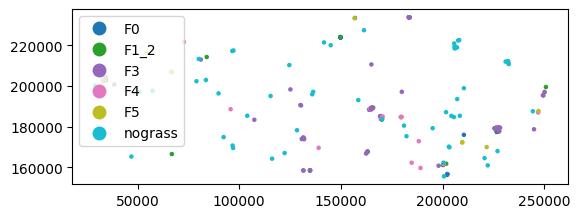

In [33]:
datagrassbwk2023.plot(column="Level4", legend=True, markersize=5)


# Creat full dataset

In [34]:
from geotessera import GeoTessera
import numpy as np
from geotessera.store import GeoTesseraZarr

#gt = GeoTessera(dataset_version='v1.1', dataset_variant='cambridge')

In [35]:
points = datagrassbwk2023.to_crs("EPSG:4326")
points = points[["Level4","geometry"]]
points

,Level4,geometry
0,F0,POINT (5.22846 50.89139)
1,F0,POINT (4.36735 51.32603)
2,F0,POINT (4.36472 51.32617)
3,F0,POINT (4.36453 51.32604)
4,F0,POINT (4.46822 51.41105)
...,...,...
10440,nograss,POINT (5.08389 50.76918)
5259,nograss,POINT (2.95434 51.07544)
16985,nograss,POINT (3.61188 51.26493)
23636,nograss,POINT (5.53921 51.21196)


In [36]:
from geotessera.store import GeoTesseraZarr

gt = GeoTesseraZarr()
print(gt.years)  # [2017, 2018, ..., 2025]


[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [37]:
coords = [(geom.x, geom.y) for geom in points.geometry]

gt = GeoTesseraZarr()
print(gt.years)  # [2017, 2018, ..., 2025]

# Sample embeddings at specific points (no download needed)
X = gt.sample_points(coords, year=2023)
print(f"Shape: {X.shape}")  # (2, 128)



Output()

[2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


Shape: (233, 128)


In [38]:
X

array([[ 0.18413036, -1.5957963 , -1.3502892 , ...,  1.1661589 ,
         4.296375  , -1.0434053 ],
       [ 1.261998  , -1.4847035 , -0.14847036, ...,  0.        ,
         3.266348  , -2.969407  ],
       [ 3.1633594 , -1.9228263 ,  1.426613  , ...,  1.9848529 ,
         2.2949862 , -1.2405331 ],
       ...,
       [ 6.394559  ,  1.721612  ,  0.9222922 , ...,  2.520932  ,
         1.721612  , -2.7053902 ],
       [ 6.315948  ,  2.7676625 , -1.1354513 , ..., -0.9935199 ,
         2.4128342 ,  0.9935199 ],
       [ 3.22724   ,  1.8441372 ,  0.9220686 , ..., -2.3051715 ,
         4.017585  ,  1.7124132 ]], dtype=float32)

In [39]:
import pandas as pd

# Convert embeddings to DataFrame
emb_df = pd.DataFrame(
    X,
    columns=[f"emb_{i}" for i in range(X.shape[1])]
)

# Keep desired columns from GeoDataFrame
out = pd.concat(
    [
        points[["Level4"]].reset_index(drop=True),
        points.geometry.x.rename("lon").reset_index(drop=True),
        points.geometry.y.rename("lat").reset_index(drop=True),
        emb_df
    ],
    axis=1
)

out

,Level4,lon,lat,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,...,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,F0,5.228464,50.891395,0.184130,-1.595796,-1.350289,4.296375,0.552391,-1.473043,-3.928114,...,-1.043405,-6.076302,-2.516448,-2.148187,-5.094273,-2.455071,-1.288912,1.166159,4.296375,-1.043405
1,F0,4.367350,51.326029,1.261998,-1.484704,-0.148470,5.419168,0.668117,0.965057,-3.489053,...,-3.266348,-6.458460,-1.187763,-4.082935,-2.969407,-2.004350,-4.379876,0.000000,3.266348,-2.969407
2,F0,4.364718,51.326169,3.163359,-1.922826,1.426613,4.217813,0.186080,-1.674720,0.062027,...,-1.984853,-4.217813,-3.349439,-1.364586,-1.426613,-2.605119,-3.907679,1.984853,2.294986,-1.240533
3,F0,4.364533,51.326043,2.823653,-3.106018,1.637719,1.807138,-3.783695,-1.863611,-2.541288,...,-0.847096,-3.162491,-1.524773,-2.993072,-2.371868,-7.172078,-3.275437,3.388383,2.371868,0.225892
4,F0,4.468216,51.411047,0.444058,0.370049,-0.962126,4.958652,0.592078,-0.592078,-2.368311,...,-1.480194,-6.956914,-1.258165,-1.924253,-2.516331,-2.146282,-4.144545,1.036136,2.368311,-3.996525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
228,nograss,5.083887,50.769175,1.878636,-0.939318,0.607794,1.215588,-0.663048,-0.221016,-0.718302,...,0.828810,-2.983716,-3.867780,-2.431176,-1.270842,-3.757272,-3.923034,0.939318,4.309813,2.099652
229,nograss,2.954339,51.075437,5.439659,2.164165,-2.632093,4.679276,0.643400,1.988692,-4.503803,...,2.690584,-3.450966,-1.228310,-6.083059,-1.813220,-0.643400,-3.743421,-1.579256,2.398129,0.701891
230,nograss,3.611883,51.264932,6.394559,1.721612,0.922292,1.660126,2.274987,2.213501,0.122972,...,-1.414181,-3.935113,-3.689169,-1.045264,2.029043,-2.336473,-3.197279,2.520932,1.721612,-2.705390
231,nograss,5.539214,51.211962,6.315948,2.767663,-1.135451,4.683737,0.354829,1.064486,-3.477320,...,2.058006,-5.038565,-1.845108,-4.967599,2.199937,-0.212897,-3.832148,-0.993520,2.412834,0.993520


In [ ]:
out.to_csv("/content/drive/Shareddrives/PRJ_SlimmeBeeldverwerking/PRJ_2026_SlimmeBeeldverwerking/Slimmebeeldverwerking/extract_embeddings/OutputTesseraEmbeddings/Tessera2023.csv", index=False)